# Phase 2: OCR Baseline
**Objective** : Extract text, bounding boxes, and confidence scores. Compare OCR on original vs. preprocessed images.

In [2]:
import sys
import os
import cv2
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.preprocessing.pipeline import render_pdf_page, to_grayscale, apply_clahe, otsu_threshold
from src.ocr.ocr_engine import extract_text_and_boxes

pdf_path = "../data/raw/Bayesian_Reflection.pdf"
original_img = render_pdf_page(pdf_path, page_num=0, dpi = 300)
preprocessed_img = otsu_threshold(apply_clahe(to_grayscale(original_img)))

ocr_results_original = extract_text_and_boxes(original_img)
ocr_results_preprocessed = extract_text_and_boxes(preprocessed_img)
print(f"Original tokens found: {len(ocr_results_original)}")
print(f"Preprocessed tokens found: {len(ocr_results_preprocessed)}")

Original tokens found: 265
Preprocessed tokens found: 265


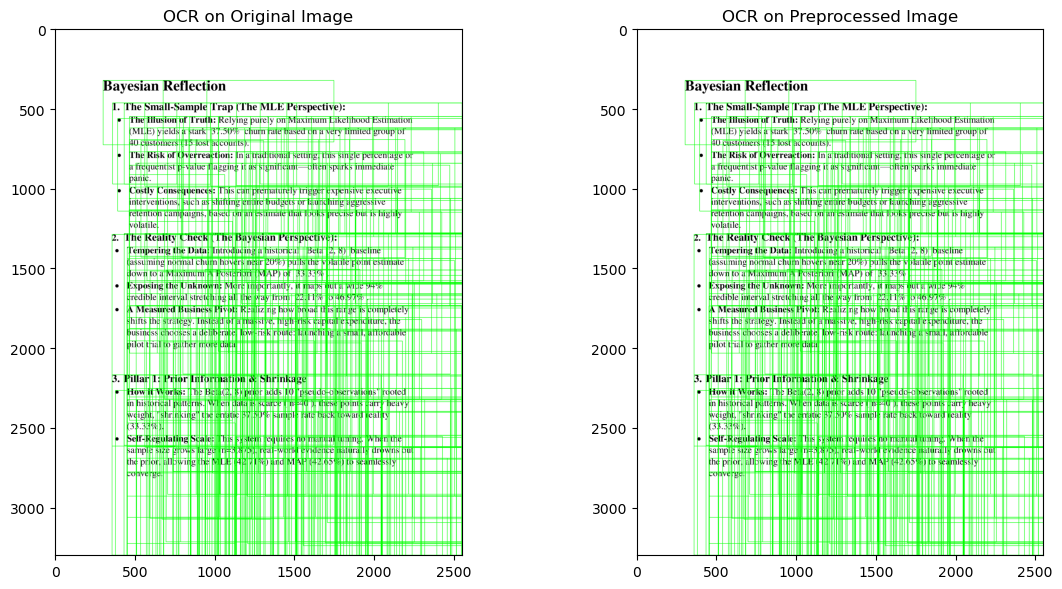

In [ ]:
def draw_ocr_boxes(img, ocr_results):
    """Draws bounding boxes and text on the image"""

    img_copy = img.copy()
    if len(img_copy.shape) == 2:  # If grayscale, convert to BGR for color drawing
        img_copy = cv2.cvtColor(img_copy, cv2.COLOR_GRAY2BGR)

    for item in ocr_results:
        bbox = item["bbox"]
        cv2.rectangle(img_copy, (bbox[0], bbox[1], bbox[2], bbox[3]), (0, 255, 0), 2) # Draw bounding box (green)

    return img_copy

img_original_boxes = draw_ocr_boxes(original_img, ocr_results_original)
img_preprocessed_boxes = draw_ocr_boxes(preprocessed_img, ocr_results_preprocessed)

plt.figure(figsize = (12,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_original_boxes, cv2.COLOR_BGR2RGB))
plt.title("OCR on Original Image")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_preprocessed_boxes, cv2.COLOR_BGR2RGB))
plt.title("OCR on Preprocessed Image")

plt.tight_layout()
plt.show()

### Observations
**Positive observations**
- Text readability is preserved.
- Headings are detected accurately.
- Paragraph alignment remains intact.
- Preprocessing did not degrade OCR performance.

**Limitations**
- False detections remain.
- Noise removal is insufficient.
- The OCR confidence is unlikely to improve much because the detected regions have not changed significantly.

Additionally, numerous thin vertical and horizontal green bounding boxes are visible, particularly in the lower portion of both images. These boxes correspond to **false positive text detections**, where the OCR engine incorrectly identifies image artifacts or noise as text.

### Limitations of the Current Preprocessing Pipeline

The current preprocessing pipeline consists of:

1. Grayscale conversion
2. Gaussian denoising
3. CLAHE (Contrast Limited Adaptive Histogram Equalization)
4. Otsu's thresholding

While these operations improve image contrast and suppress minor noise, they do not effectively remove structural artifacts such as:

- Small connected noise components
- Thin vertical or horizontal streaks
- Border artifacts
- Non-text connected regions

As a result, the OCR engine continues to detect these artifacts as text regions, leading to a high number of false positives.

### Mitigation Strategies

The OCR performance can be improved by extending the preprocessing pipeline with additional image enhancement techniques:

- **Morphological Opening:** Removes small isolated noise components and thin artifacts that are incorrectly detected as text.
- **Deskewing:** Corrects document orientation, improving text alignment and OCR recognition accuracy.
- **Adaptive Thresholding:** Can perform better than global Otsu thresholding under uneven lighting or varying background intensity.
- **Contour-Based Filtering:** Removes connected components that are too small or have aspect ratios inconsistent with textual regions.
- **Connected Component Analysis (CCA):** Filters out non-text regions before OCR processing.
- **Noise Removal Based on Area Thresholds:** Eliminates tiny blobs and artifacts that commonly generate false detections.

### Recommended Improved Pipeline

```text
PDF
 ↓
Render Page
 ↓
Grayscale Conversion
 ↓
Gaussian Denoising
 ↓
CLAHE
 ↓
Otsu Thresholding
 ↓
Morphological Opening
 ↓
Deskewing
 ↓
Contour/Component Filtering
 ↓
OCR
```


In [4]:
import json
# Print the first 5 tokens to verify the JSON structure matches the roadmap
print("Sample OCR Output (Preprocessed):")
print(json.dumps(ocr_results_preprocessed[:5], indent=4))

Sample OCR Output (Preprocessed):
[
    {
        "text": "Bayesian",
        "bbox": [
            301,
            322,
            651,
            405
        ],
        "confidence": 0.96
    },
    {
        "text": "Reflection",
        "bbox": [
            677,
            322,
            1071,
            387
        ],
        "confidence": 0.96
    },
    {
        "text": "1.",
        "bbox": [
            360,
            463,
            404,
            510
        ],
        "confidence": 0.94
    },
    {
        "text": "The",
        "bbox": [
            433,
            464,
            541,
            510
        ],
        "confidence": 0.93
    },
    {
        "text": "Small-Sample",
        "bbox": [
            562,
            463,
            953,
            523
        ],
        "confidence": 0.9
    }
]
